In [1]:
import numpy as np
from numpy.linalg import inv as inv
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.datasets import make_spd_matrix
from sklearn.covariance import graphical_lasso, GraphicalLasso, GraphicalLassoCV
from tqdm.notebook import tqdm

from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import scipy.cluster.hierarchy as sch
from scipy.stats import chi2
from scipy.stats import multivariate_normal
from scipy.optimize import minimize

from numpy.lib.stride_tricks import sliding_window_view

from statsmodels.stats.multitest import fdrcorrection
from statsmodels.tsa.seasonal import STL

%matplotlib inline

# fix random seed
np.random.seed(39)

import warnings
warnings.filterwarnings('ignore')  # <- remember to comment this if something breaks and you get confused

In [2]:
def is_pos_def(A):
    if is_symmetric(A):
        try:
            np.linalg.cholesky(A)
            return True
        except np.linalg.LinAlgError:
            return False
    else:
        return False

def is_symmetric(a, tol=1e-8):
    return np.all(np.abs(a-a.T) < tol)

In [3]:
stock_files = os.path.join("/home/dink/Documents/Research/data/stocks", "*.csv")
stock_list = glob.glob(stock_files)

In [4]:
dfs = []
for filename in stock_list:
    sample_df = pd.read_csv(filename)
    head_tail = os.path.split(filename)
    stock_name = head_tail[1].split('.')[0]
    sample_df['Stock'] = ''.join(stock_name)
    dfs.append(sample_df)


df = pd.concat(dfs, axis=0, ignore_index=True)
df = df.loc[:, ["Date", "Close", "Stock"]]
df = df.pivot(index="Date", columns="Stock", values="Close")

In [5]:
df.head()

Stock,AAL,AAPL,ALK,AMZN,ASML,AXP,BA,CLX,CSCO,DB,...,PG,PYPL,RCL,SPY,STM,TSLA,TSM,TWTR,VZ,WFC
Date,,,,,,,,,,,,,,,,,,,,,
2017-02-22,46.320000,34.277500,97.250000,855.609985,123.830002,79.860001,175.360001,135.919998,34.090000,19.650000,...,91.440002,42.419998,95.949997,236.279999,15.11,54.702000,32.070000,16.080000,49.669998,58.360001
2017-02-23,46.099998,34.132500,95.889999,852.190002,123.779999,80.050003,176.860001,135.830002,34.040001,19.709999,...,91.129997,42.529999,95.529999,236.440002,15.18,51.198002,31.750000,16.030001,50.310001,58.490002
2017-02-24,46.279999,34.165001,97.010002,845.239990,122.529999,79.760002,177.440002,136.369995,34.320000,19.129999,...,91.050003,43.070000,96.150002,236.740005,15.00,51.400002,31.920000,15.980000,50.599998,57.810001
2017-02-27,46.320000,34.232498,97.839996,848.640015,122.900002,80.169998,179.429993,136.440002,34.259998,19.580000,...,90.889999,42.639999,96.690002,237.110001,15.53,49.245998,31.530001,16.059999,49.939999,58.060001
2017-02-28,46.360001,34.247501,97.820000,845.039978,121.690002,80.059998,180.229996,136.809998,34.180000,19.690001,...,91.070000,42.000000,96.099998,236.470001,15.26,49.998001,31.469999,15.770000,49.630001,57.880001


In [6]:
df.columns

Index(['AAL', 'AAPL', 'ALK', 'AMZN', 'ASML', 'AXP', 'BA', 'CLX', 'CSCO', 'DB',
       'DIS', 'ETSY', 'FB', 'GIS', 'GOOG', 'INTC', 'JPM', 'K', 'LUV', 'MA',
       'MCHP', 'MS', 'MSFT', 'NCLH', 'NFLX', 'NVDA', 'NXPI', 'ON', 'ORCL',
       'PEP', 'PFE', 'PG', 'PYPL', 'RCL', 'SPY', 'STM', 'TSLA', 'TSM', 'TWTR',
       'VZ', 'WFC'],
      dtype='object', name='Stock')

In [7]:
log_diff = np.log(df/df.shift(1)).dropna()
log_diff = (log_diff - log_diff.mean(axis=0))
log_diff.tail()

Stock,AAL,AAPL,ALK,AMZN,ASML,AXP,BA,CLX,CSCO,DB,...,PG,PYPL,RCL,SPY,STM,TSLA,TSM,TWTR,VZ,WFC
Date,,,,,,,,,,,,,,,,,,,,,
2022-02-14,-0.009517,0.000162,0.003386,0.011137,-0.001841,0.002102,-0.010842,-0.007677,-0.013860,-0.004270,...,0.002431,-0.010910,-0.014408,-0.003758,-0.013365,0.015972,-0.011344,-0.004797,-0.001002,-0.007882
2022-02-15,0.078547,0.021628,0.050017,0.007610,0.043073,0.028140,0.035818,-0.002252,0.019878,0.020465,...,0.000066,0.010963,0.041767,0.015514,0.040042,0.049732,0.037849,0.034904,0.001624,0.009158
2022-02-16,-0.000305,-0.002650,0.007055,0.009097,0.009970,0.001309,0.005357,-0.009661,-0.000780,-0.011151,...,0.007115,-0.044257,0.009224,0.000636,0.008366,-0.001147,-0.008460,-0.020816,0.000685,-0.004081
2022-02-17,-0.031643,-0.022759,-0.023427,-0.023061,-0.021753,-0.014260,-0.024880,0.032850,0.027222,-0.020302,...,0.010946,-0.050224,-0.022192,-0.022077,-0.051142,-0.054473,-0.032605,-0.023207,0.003301,-0.034789
2022-02-18,-0.018639,-0.010660,-0.001299,-0.014362,-0.005321,-0.004959,-0.021673,0.030539,0.025081,-0.008904,...,0.000056,-0.015554,-0.017069,-0.006980,-0.010512,-0.024538,-0.004809,-0.032433,0.004591,-0.009266


In [8]:
log_diff.mean(axis=0)

Stock
AAL     4.081702e-19
AAPL    8.577091e-19
ALK     1.236921e-18
AMZN    3.157803e-19
ASML   -1.951219e-19
AXP    -2.964750e-19
BA      1.315522e-18
CLX     1.792640e-19
CSCO    4.247177e-19
DB     -1.396880e-18
DIS     3.861070e-20
ETSY   -3.943807e-18
FB      1.337585e-19
GIS     5.646814e-19
GOOG    5.253813e-19
INTC    1.218995e-18
JPM    -1.151426e-19
K      -7.997930e-20
LUV     8.687407e-20
MA      1.034215e-19
MCHP    1.751271e-19
MS      2.344221e-19
MSFT   -4.426441e-19
NCLH   -5.653709e-19
NFLX   -4.909074e-19
NVDA    5.515814e-20
NXPI    8.673617e-19
ON     -3.378436e-19
ORCL    1.094889e-18
PEP     1.799534e-19
PFE    -2.040851e-19
PG      5.993277e-19
PYPL    1.315522e-18
RCL     7.611823e-19
SPY    -1.627165e-19
STM    -8.590880e-19
TSLA   -1.417564e-18
TSM    -2.753770e-18
TWTR    2.300094e-18
VZ      2.371800e-19
WFC     3.281909e-19
dtype: float64

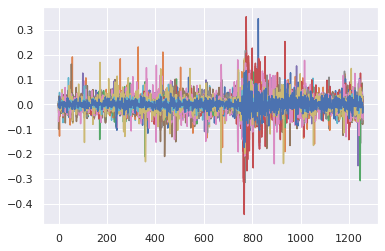

In [9]:
plt.plot(log_diff.values);

In [10]:
for i,col in enumerate(log_diff.columns):
    print(i, col)

0 AAL
1 AAPL
2 ALK
3 AMZN
4 ASML
5 AXP
6 BA
7 CLX
8 CSCO
9 DB
10 DIS
11 ETSY
12 FB
13 GIS
14 GOOG
15 INTC
16 JPM
17 K
18 LUV
19 MA
20 MCHP
21 MS
22 MSFT
23 NCLH
24 NFLX
25 NVDA
26 NXPI
27 ON
28 ORCL
29 PEP
30 PFE
31 PG
32 PYPL
33 RCL
34 SPY
35 STM
36 TSLA
37 TSM
38 TWTR
39 VZ
40 WFC


In [11]:
log_diff.index

Index(['2017-02-23', '2017-02-24', '2017-02-27', '2017-02-28', '2017-03-01',
       '2017-03-02', '2017-03-03', '2017-03-06', '2017-03-07', '2017-03-08',
       ...
       '2022-02-07', '2022-02-08', '2022-02-09', '2022-02-10', '2022-02-11',
       '2022-02-14', '2022-02-15', '2022-02-16', '2022-02-17', '2022-02-18'],
      dtype='object', name='Date', length=1258)

In [12]:
log_diff.index.values[734]

'2020-01-24'

In [13]:
lrt_vals = np.loadtxt('/home/dink/Documents/Research/Correlation-Changepoint-Detection/results/2022052500/lrt_results.csv', delimiter=',')

In [14]:
lrt_vals = lrt_vals[:, 0:10]
lrt_vals.shape

(1058, 10)

In [15]:
lrt_vals_padded = np.pad(lrt_vals, [(100, 100), (0,0)], mode='constant')
lrt_vals_padded.shape

(1258, 10)

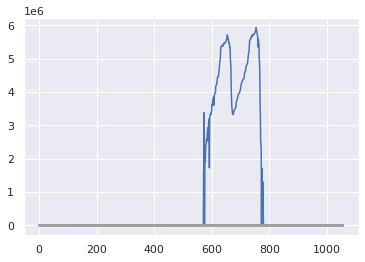

In [16]:
plt.plot(lrt_vals);

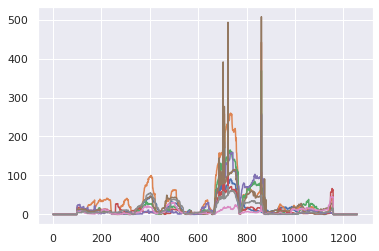

In [17]:
plt.plot(lrt_vals_padded[:, 1:-1]);

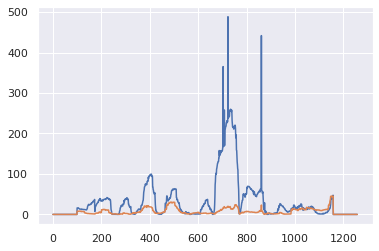

In [18]:
plt.plot(lrt_vals_padded[:, 2])
plt.plot(lrt_vals_padded[:, 7])

In [19]:
log_diff.columns[7]

'CLX'

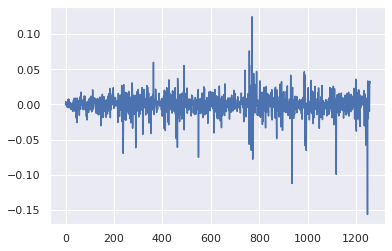

In [20]:
plt.plot(log_diff.values[:, 7])

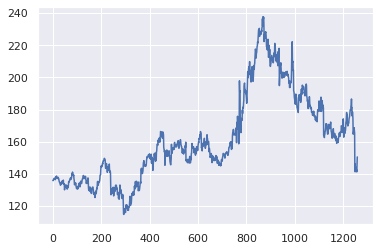

In [21]:
plt.plot(df.values[:, 7])

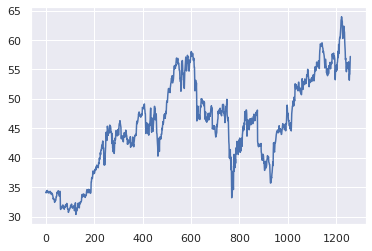

In [22]:
plt.plot(df.values[:, 8])

In [23]:
import matplotlib.dates as mdates
from matplotlib.pyplot import figure

In [24]:
mat_two = np.loadtxt('/home/dink/Documents/Research/Correlation-Changepoint-Detection/results/2022052500/matrix_2.csv', delimiter=',')

In [25]:
def symmetrize_from_vector_alt(a, dim):
    """
    Turns a vector of lower triangular matrix entries into symmetric matrix
    """
    A = np.zeros((dim,dim))
    A[np.tril_indices(A.shape[0], k = 0)] = a
    A = A + A.T - np.diag(np.diag(A))

    return A
mat_two = symmetrize_from_vector_alt(mat_two, 41)

In [26]:
set(np.nonzero(mat_two)[0])

{3, 14, 22}

In [27]:
log_diff.columns[[3, 4, 22]]

Index(['AMZN', 'ASML', 'MSFT'], dtype='object', name='Stock')

In [28]:
log_diff.index.freq = 'd'

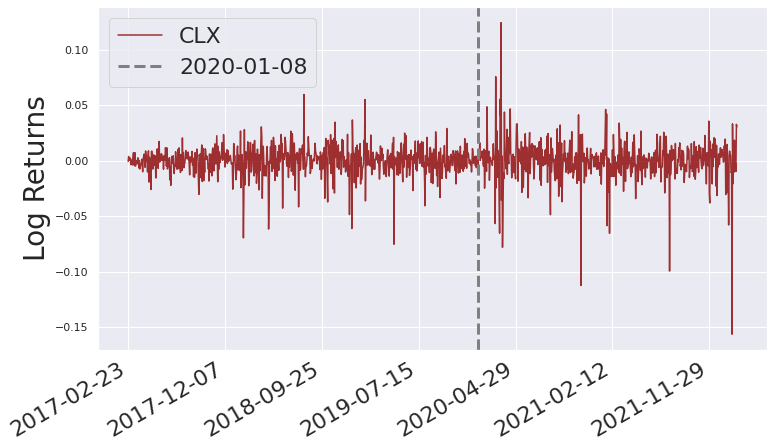

In [69]:
figure(figsize=(12, 7))
log_diff.loc[:, 'CLX'].plot(color='darkred', alpha=0.8)
plt.xlabel('')
plt.ylabel('Log Returns', fontsize=28)
plt.axvline(x=723, ls='--', color='gray', label='2020-01-08', linewidth=3)
plt.xticks(fontsize=22);
plt.legend(loc='upper left', fontsize=22)
plt.gcf().autofmt_xdate()

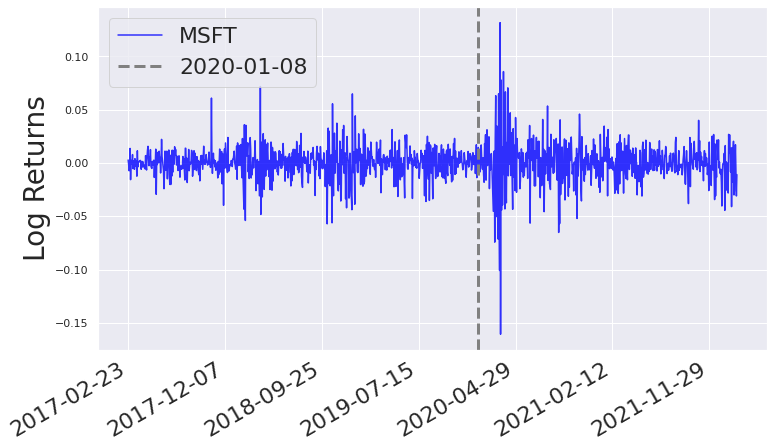

In [70]:
figure(figsize=(12, 7))
log_diff.loc[:, 'MSFT'].plot(color='blue', alpha=0.8)
plt.xlabel('')
plt.ylabel('Log Returns', fontsize=28)
plt.axvline(x=723, ls='--', color='gray', label='2020-01-08', linewidth=3)
plt.legend()
plt.xticks(fontsize=22);
plt.legend(loc='upper left', fontsize=22)
plt.gcf().autofmt_xdate()

In [45]:
temp_df = pd.DataFrame()
temp_df.index = log_diff.index
temp_df.loc[:, 'AMZN, ASML, MSFT'] = lrt_vals_padded[:, 2]
temp_df.loc[:, 'CLX'] = lrt_vals_padded[:, 7]

In [46]:
temp_df_two = pd.DataFrame()
temp_df_two.index = log_diff.index
for i in range(lrt_vals_padded.shape[1]):
    if i not in [0, 2, 7, 9]:
        temp_df_two.loc[:, str(i)] = lrt_vals_padded[:, i]

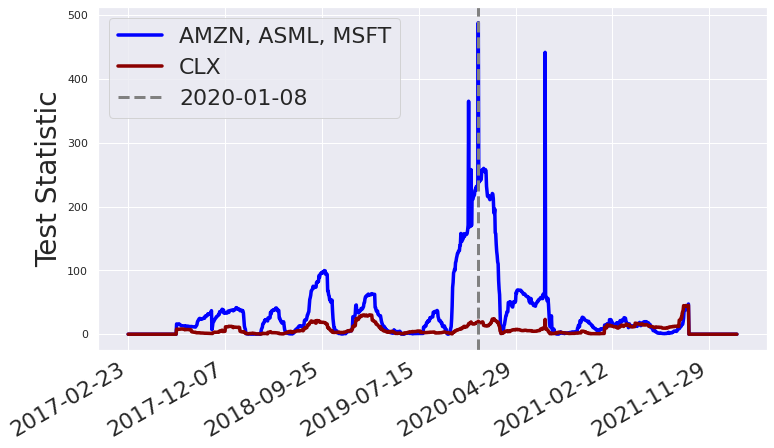

In [68]:
temp_df.plot(figsize=(12, 7), color=['blue', 'darkred'], linewidth=3.5)
#plt.title('Test Statistics for Clusters 2 & 7', fontsize=14)
plt.axvline(x=723, ls='--', color='gray', label='2020-01-08', linewidth=3)
plt.ylabel('Test Statistic', fontsize=28)
plt.xlabel('')
plt.xticks(fontsize=22);
plt.legend(loc='upper left', fontsize=22)
plt.gcf().autofmt_xdate()

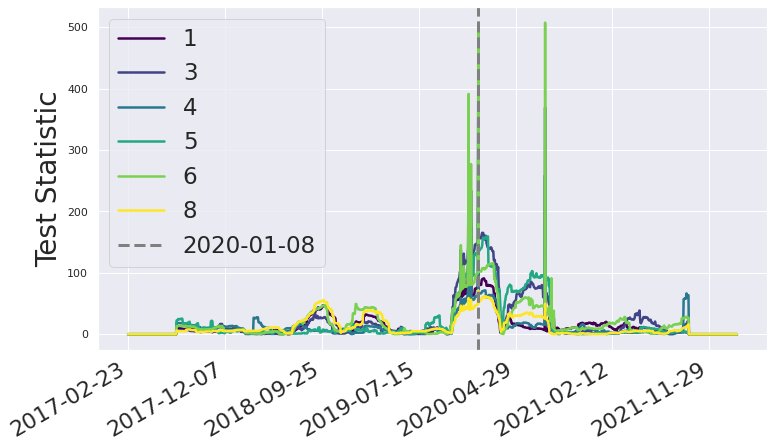

In [67]:
temp_df_two.plot(figsize=(12, 7), cmap='viridis', legend=False, linewidth=2.5)
#plt.title('Test Statistics for Other Clusters', fontsize=14)
plt.axvline(x=723, ls='--', color='gray', label='2020-01-08', linewidth=3)
plt.ylabel('Test Statistic', fontsize=28)
plt.legend()
plt.xticks(fontsize=22);
plt.legend(loc='upper left', fontsize=23)
plt.xlabel('');
plt.gcf().autofmt_xdate()

In [89]:
log_diff.index

Index(['2017-02-23', '2017-02-24', '2017-02-27', '2017-02-28', '2017-03-01',
       '2017-03-02', '2017-03-03', '2017-03-06', '2017-03-07', '2017-03-08',
       ...
       '2022-02-07', '2022-02-08', '2022-02-09', '2022-02-10', '2022-02-11',
       '2022-02-14', '2022-02-15', '2022-02-16', '2022-02-17', '2022-02-18'],
      dtype='object', name='Date', length=1258)

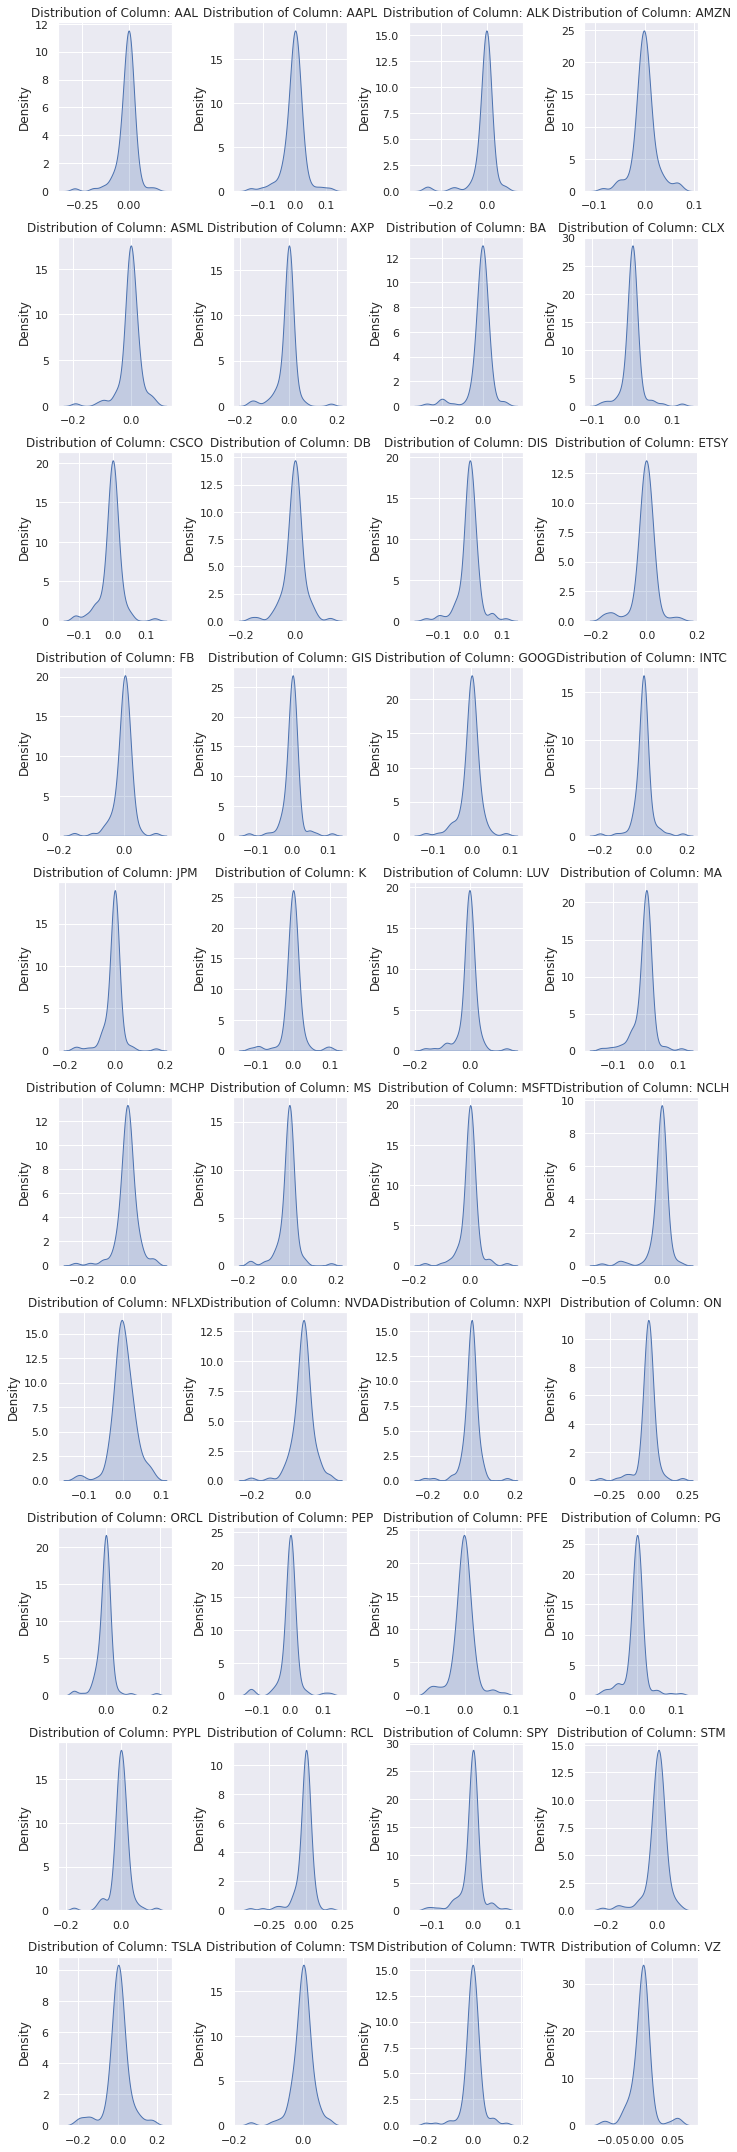

In [80]:
fig, axes = plt.subplots(nrows=10, ncols=4, figsize=(10, 30), sharex=False, sharey=False)
axes = axes.ravel()  # array to 1D
cols = log_diff.columns  # create a list of dataframe columns to use

for col, ax in zip(cols, axes):
    data = log_diff[[col]].iloc[675:775]  # select the data
    sns.kdeplot(data=data, x=col, shade=True, ax=ax)
    ax.set(title=f'Distribution of Column: {col}', xlabel=None)
    
fig.tight_layout()
plt.show()

<AxesSubplot:ylabel='Density'>

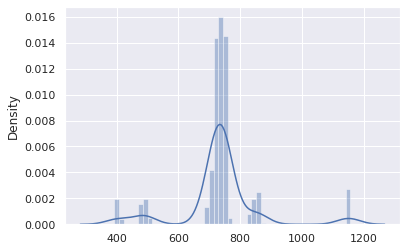

In [62]:
k = 50
all_indx = []
for i in range(lrt_vals_padded.shape[1]):
    idx = np.argpartition(lrt_vals_padded[:, i], -k)[-k:]  # Indices not sorted

    all_indx.append(idx[np.argsort(lrt_vals_padded[:, i][idx])][::-1])
sns.distplot(np.array(all_indx).flatten())

In [47]:
log_diff.index.values[723], log_diff.index.values[861]

('2020-01-08', '2020-07-27')

In [43]:
log_diff.shape

(1258, 41)

In [45]:
lrt_vals_padded.shape

(1258, 10)

In [27]:
log_diff.to_csv("/home/dink/Documents/Research/data/logdiff.csv")

In [28]:
np.savetxt('/home/dink/Documents/Research/data/logdiff_vals.csv', log_diff.values, delimiter=',')

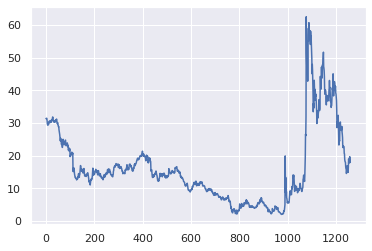

In [6]:
plt.plot(df.loc[:, 'AMC'].values)

In [7]:
seasonal_df = pd.DataFrame()
trend_df = pd.DataFrame()
resid_df = pd.DataFrame()
for i in tqdm(range(df.shape[1])):
    model = STL(df.values[:, i], period=252) # very approximate seasonality here, holidays+weekends etc
    result = model.fit()
    seasonal_df[df.columns[i]] = result.seasonal
    trend_df[df.columns[i]] = result.trend
    resid_df[df.columns[i]] = result.resid
seasonal_df.index = df.index
trend_df.index = df.index
resid_df.index = df.index

  0%|          | 0/12 [00:00<?, ?it/s]

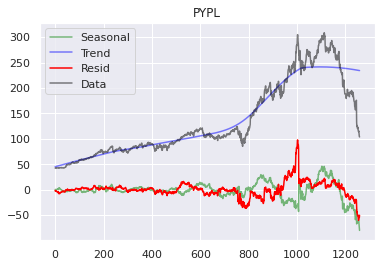

In [8]:
plot_idx = 8
plt.plot(seasonal_df.values[:, plot_idx], color='green', label='Seasonal', alpha=0.5)
plt.plot(trend_df.values[:, plot_idx], color='blue', label='Trend', alpha=0.5)
plt.plot(resid_df.values[:, plot_idx], color='red', label='Resid')
plt.plot(df.values[:, plot_idx], color='black', label='Data', alpha=0.5)
plt.title(seasonal_df.columns[plot_idx]);
plt.legend(loc='best');

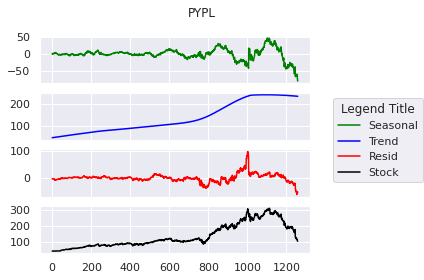

In [9]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4)

line_labels = ['Seasonal', 'Trend', 'Resid', 'Stock']
l1 = ax1.plot(seasonal_df.values[:, plot_idx], color='green')
l2 = ax2.plot(trend_df.values[:, plot_idx], color='blue')
l3 = ax3.plot(resid_df.values[:, plot_idx], color='red')
l4 = ax4.plot(df.values[:, plot_idx], color='black')
fig.legend([l1, l2, l3, l4],     # The line objects
           labels=line_labels,   # The labels for each line
           loc="center right",   # Position of legend
           borderaxespad=0.1,    # Small spacing around legend box
           title="Legend Title"  # Title for the legend
           )
plt.subplots_adjust(right=0.75)
plt.suptitle(seasonal_df.columns[plot_idx]);

In [10]:
from sklearn import covariance, preprocessing

scaler = preprocessing.StandardScaler()
resid_scaled = scaler.fit_transform(resid_df.values)
resid_scaled

array([[ 0.85993209, -0.37871229,  0.35322936, ...,  0.34652282,
         0.28819412,  0.16827596],
       [ 0.77310692, -0.48900819,  0.25675531, ...,  0.14818307,
         0.16319952, -0.0147026 ],
       [ 0.70714191, -0.5432549 ,  0.37580764, ..., -0.08262176,
         0.09169055, -0.07948732],
       ...,
       [-1.19769812,  0.09944201, -2.54901867, ..., -1.23978161,
        -1.52467664, -2.01055348],
       [-1.27634945,  0.3779115 , -2.87072812, ..., -1.44433738,
        -1.76973203, -2.34062276],
       [-1.4421088 ,  0.52021097, -2.61035018, ..., -1.40785075,
        -1.33256118, -2.11411572]])

In [11]:
resid_scaled.mean(axis=0), resid_scaled.std(axis=0)

(array([ 0.00000000e+00,  1.69311216e-17,  2.25748288e-17, -3.38622432e-17,
        -2.82185360e-17,  0.00000000e+00, -9.02993151e-17,  2.25748288e-17,
        -1.04408583e-16, -2.25748288e-17,  0.00000000e+00,  7.90119007e-17]),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]))

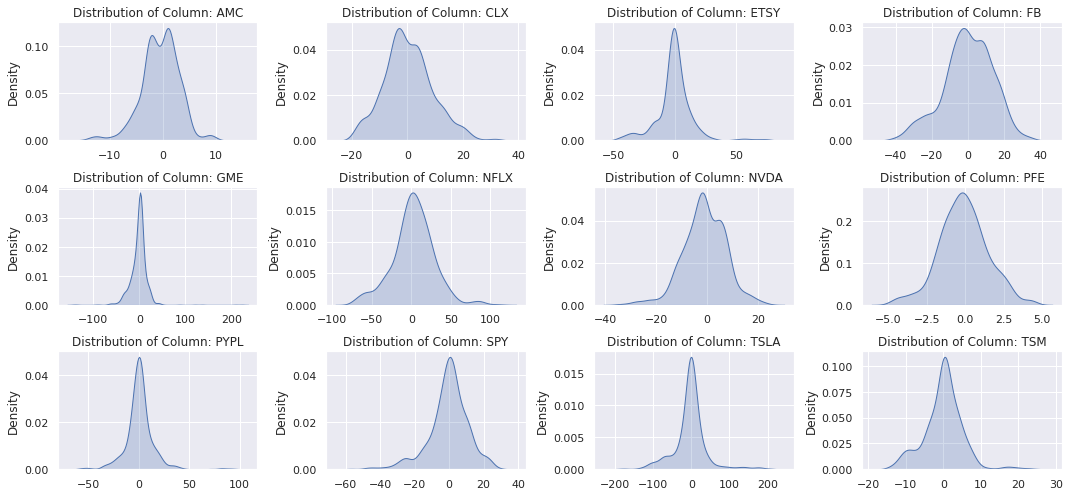

In [12]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(15, 7), sharex=False, sharey=False)
axes = axes.ravel()  # array to 1D
cols = resid_df.columns  # create a list of dataframe columns to use

for col, ax in zip(cols, axes):
    data = resid_df[[col]]  # select the data
    sns.kdeplot(data=data, x=col, shade=True, ax=ax)
    ax.set(title=f'Distribution of Column: {col}', xlabel=None)
    
fig.tight_layout()
plt.show()

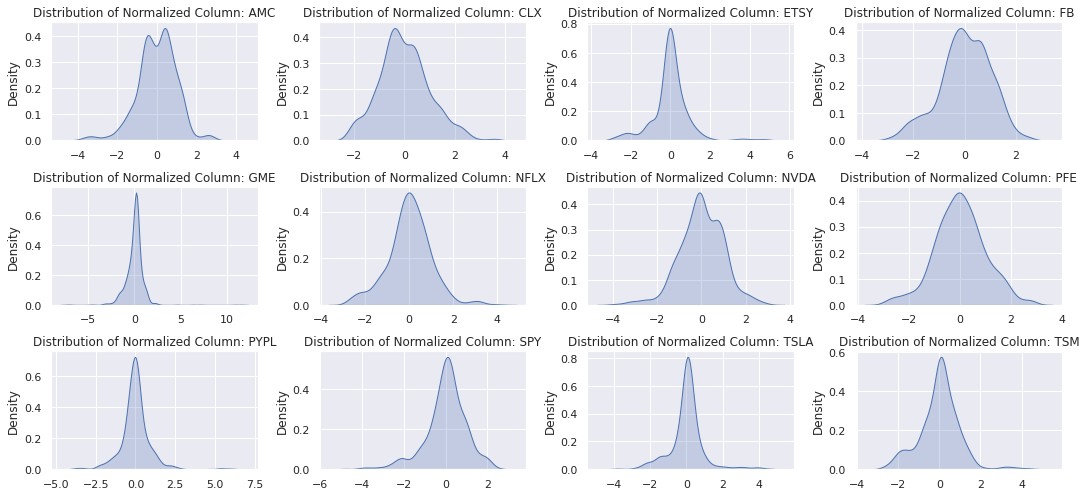

In [13]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(15, 7), sharex=False, sharey=False)
axes = axes.ravel()  # array to 1D
cols = resid_df.columns  # create a list of dataframe columns to use

for i, (col, ax) in enumerate(zip(cols, axes)):
    data = resid_scaled[:, i]  # select the data
    sns.kdeplot(data=data, shade=True, ax=ax)
    ax.set(title=f'Distribution of Normalized Column: {col}', xlabel=None)
    i += 1
    
fig.tight_layout()
plt.show()

In [14]:
resid_scaled.shape, resid_df.iloc[715].name

((1259, 12), '2019-12-24')

In [15]:
# fit GraphicalLasso on FIRST HALF(-ish) of data - up to XMAS 2019
#ret = GraphicalLasso(max_iter=1000, alpha=0.01, tol=1e-8).fit(resid_scaled[0:715, :])

# or the whole thing? Sure...
ret = GraphicalLasso(max_iter=1000, alpha=0.001, tol=1e-8).fit(resid_scaled)

precision = ret.precision_.copy()
clust_dist_mat = np.abs(precision)
np.fill_diagonal(clust_dist_mat, 0.0)
clust_dist_mat = clust_dist_mat.max() - clust_dist_mat
np.fill_diagonal(clust_dist_mat, 0.0)

<AxesSubplot:>

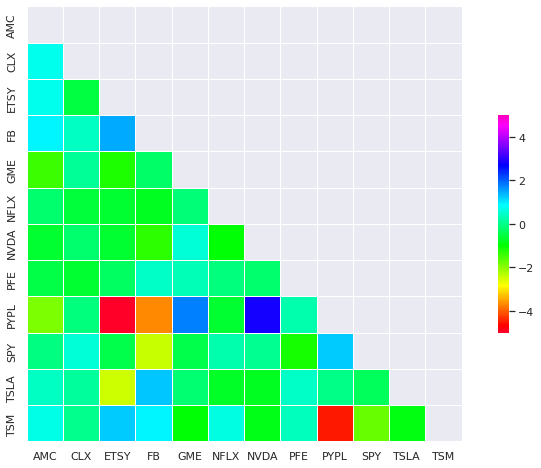

In [16]:
mask = np.triu(np.ones_like(precision, dtype=bool))
f, ax = plt.subplots(figsize=(13, 8))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(precision, mask=mask, cmap='gist_rainbow', vmin=-5.0, vmax=5.0, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, xticklabels=resid_df.columns, 
            yticklabels=resid_df.columns)

<AxesSubplot:>

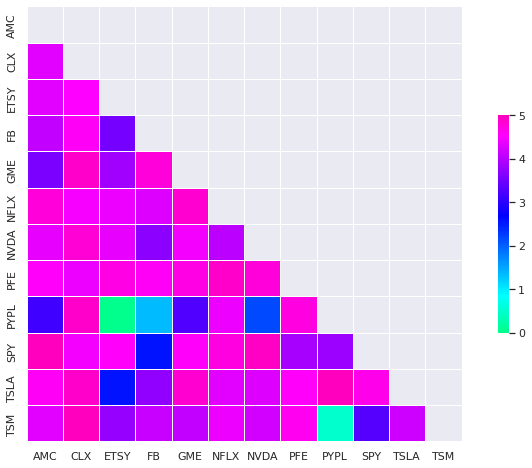

In [17]:
mask = np.triu(np.ones_like(clust_dist_mat, dtype=bool))
f, ax = plt.subplots(figsize=(13, 8))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(clust_dist_mat, mask=mask, cmap='gist_rainbow', vmin=0.0, vmax=5.0, center=0.0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, xticklabels=resid_df.columns, 
            yticklabels=resid_df.columns)

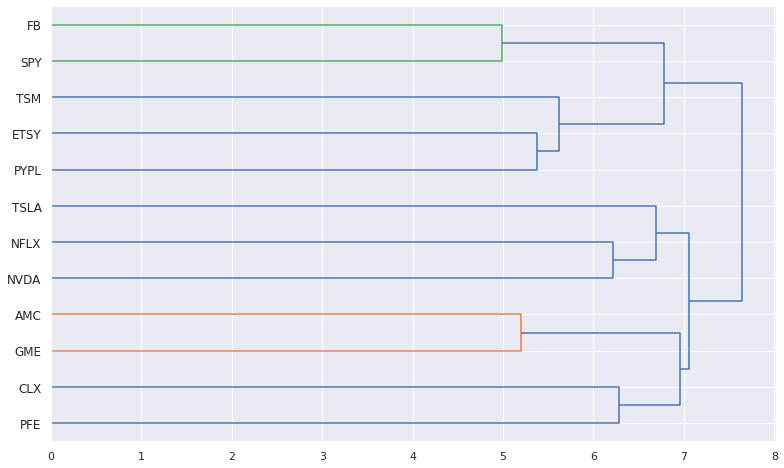

In [18]:
pairwise_distances = sch.distance.pdist(clust_dist_mat)
Z = linkage(pairwise_distances,
            method='average'  # dissimilarity metric: max distance across all pairs of 
                               # records between two clusters
    )
# calculate full dendrogram and visualize it
plt.figure(figsize=(13, 8))
dendrogram(
            Z,
            orientation='right',
            labels=resid_df.columns,
            distance_sort='descending',
            show_leaf_counts=False
          )
plt.show()

In [19]:
cutree1 = hierarchy.cut_tree(Z, n_clusters=2).squeeze()
cutree1, resid_df.columns

(array([0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1]),
 Index(['AMC', 'CLX', 'ETSY', 'FB', 'GME', 'NFLX', 'NVDA', 'PFE', 'PYPL', 'SPY',
        'TSLA', 'TSM'],
       dtype='object'))

In [20]:
og_l = multivariate_normal.logpdf(data.T, mean=np.zeros(data.shape[0]), cov=C).sum()
    
    return log_l
    
    return log_l*(N/2)prec = ret.precision_
basis_matrices = []
for i in range(max(set(cutree1))+1): # iterate over clusters
    idxs = np.where(cutree1 == i)[0] # indexes for given cluster
    A = np.zeros(prec.shape) # blank A matrix
    for idx in idxs: # loop over indexes
        for idx2 in idxs: # loop over indexes
            A[idx][idx2] = prec[idx][idx2].copy() # set i,j entry to be the entry from precision matrix for given cluster
    basis_matrices.append(A)
basis_matrices = np.array(basis_matrices)
basis_matrices.shape

(2, 12, 12)

In [21]:
"""
Degenerate solution
"""
use_degenerate_soln = True
if use_degenerate_soln:
    basis_matrices = []
    tril_idx = np.tril_indices(n=prec.shape[0], k=0, m=prec.shape[1])
    for i in range(tril_idx[0].shape[0]):
        B = np.zeros(prec.shape)
        first, second = tril_idx[0][i], tril_idx[1][i]
        B[first, second] = prec[first, second].copy()
        B[second, first] = prec[second, first].copy()
        if B.any():  # check if any non-zero entries - there's one with only zeros
            basis_matrices.append(B.copy())
basis_matrices = np.array(basis_matrices)
basis_matrices.shape

(77, 12, 12)

<AxesSubplot:>

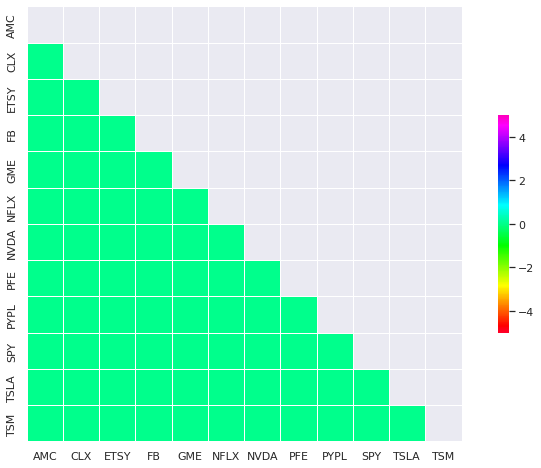

In [22]:
mask = np.triu(np.ones_like(basis_matrices[0], dtype=bool))
f, ax = plt.subplots(figsize=(13, 8))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(basis_matrices[0], mask=mask, cmap='gist_rainbow', vmin=-5.0, vmax=5.0, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, xticklabels=resid_df.columns, 
            yticklabels=resid_df.columns)

<AxesSubplot:>

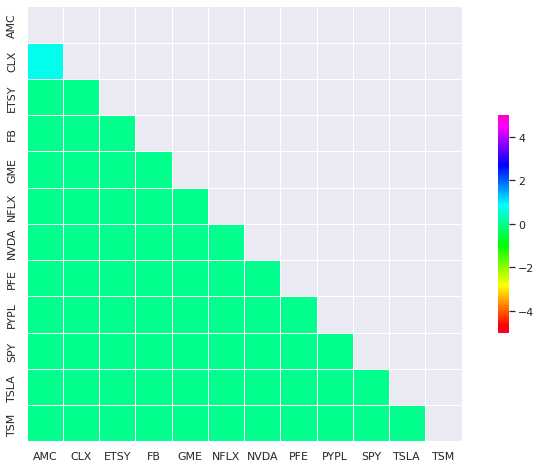

In [23]:
mask = np.triu(np.ones_like(basis_matrices[1], dtype=bool))
f, ax = plt.subplots(figsize=(13, 8))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(basis_matrices[1], mask=mask, cmap='gist_rainbow', vmin=-5.0, vmax=5.0, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, xticklabels=resid_df.columns, 
            yticklabels=resid_df.columns)

In [24]:
leftover_basis_matrix = precision - basis_matrices.sum(axis=0)

<AxesSubplot:>

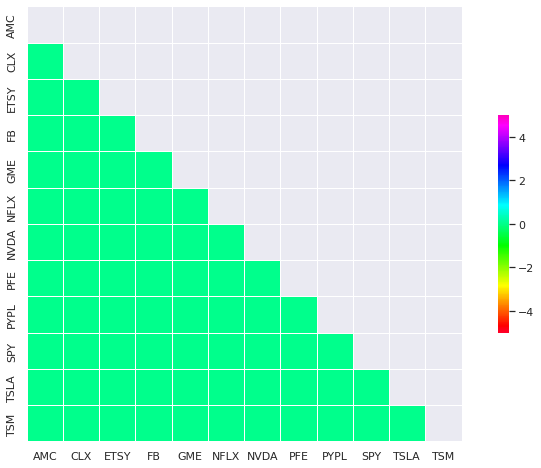

In [25]:
mask = np.triu(np.ones_like(leftover_basis_matrix, dtype=bool))
f, ax = plt.subplots(figsize=(13, 8))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(leftover_basis_matrix, mask=mask, cmap='gist_rainbow', vmin=-5.0, vmax=5.0, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, xticklabels=resid_df.columns, 
            yticklabels=resid_df.columns)

In [26]:
basis_matrices_full = np.concatenate((basis_matrices, np.expand_dims(leftover_basis_matrix, 0)), 0)
basis_matrices_full.sum(axis=0) == ret.precision_

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True

In [27]:
is_pos_def(basis_matrices_full.sum(axis=0))

True

In [28]:
for mat in basis_matrices_full:
    assert is_symmetric(mat), "Not Symmetric"

In [29]:
is_pos_def(basis_matrices.sum(axis=0))

True

In [30]:
for mat in basis_matrices:
    assert is_symmetric(mat), "Not Symmetric"

In [31]:
"""
As it turns out, this all holds true (pos_def specifically) and is great up here

But, when performing the optimization, the precision matrix from the summation is no longer positive definite
(BIG issue)

No idea how to fix this

Also the iterative solution runs into a case where the matrix is singular (identifiability problems?)

Also no idea how to fix this
""";

In [32]:
def gradient_descent_step_single(coeffs_zero, H_s, C, M, alpha, N, to_change=None):
    coeffs_new = np.zeros(coeffs_zero.shape)
    psi_hat = (coeffs_zero.reshape(-1, 1, 1)*H_s).sum(0)
    diff = 0
    inv_psi_hat = inv(psi_hat)
    for h in range(M):
        if to_change == None or to_change == h:
            grad_log_l_h = np.trace(inv_psi_hat.dot(H_s[h])) - np.trace(H_s[h].dot(C))
            #grad_log_l_h = grad_log_l_h*(N/2)
            diff += np.abs(alpha*grad_log_l_h)
            coeffs_new[h] = coeffs_zero[h] + alpha*grad_log_l_h
        else:
            coeffs_new[h] = coeffs_zero[h]
        
    return coeffs_new, diff

def gradient_descent_single(coeffs_zero, H_s, C, M, N, dim, alpha=0.01, iters=15, to_change=None):
    coeffs_imo = coeffs_zero
    best_likelihood = calc_likelihood_precision(coeffs_imo, H_s, C, N=N, P=dim)
    best_coeffs = coeffs_imo.copy()
    for i in range(iters):
        #print(coeffs_imo)
        coeffs_imo, diff = gradient_descent_step_single(coeffs_imo, H_s, C, M, alpha=alpha, 
                                                        N=N, to_change=to_change)
        new_likelihood = calc_likelihood_precision(coeffs_imo, H_s, C, N=N, P=dim)
        better = False
        if new_likelihood > best_likelihood:
            best_likelihood = new_likelihood
            best_coeffs = coeffs_imo.copy()
            better = True
        #print(diff, better, best_coeffs, coeffs_imo)
    #print(coeffs_imo)
    
    return best_coeffs

#############################
def calc_matrices_precision(psi_hat, H_s, C, dim):
    A = np.zeros((dim, dim))
    B = np.zeros((dim,))
    inv_psi_hat = inv(psi_hat) # calculate psi_hat inverse
    for g in range(dim):
        for h in range(dim):
            mult = ((inv_psi_hat.dot(H_s[g])).dot(inv_psi_hat)).dot(H_s[h])
            lhs = np.trace(mult)
            A[g, h] = lhs
        rhs = np.trace(inv_psi_hat.dot(H_s[g])) - np.trace(C.dot(H_s[g]))
        B[g] = rhs
    
    return A, B
##############################

def iterative_soln_precision(coeffs_zero, H_s, C, dim, iters=5):
    s_imo = coeffs_zero
    for it in range(iters):
        psi_hat = (s_imo.reshape(-1, 1, 1)*H_s).sum(0) # calculate psi_hat
        A, B = calc_matrices_precision(psi_hat, H_s, C, dim)
        #print(A, B)
        ####################
        #t_i = inv(A).dot(B)
        t_i = np.linalg.solve(A, B)
        #t_i = np.linalg.lstsq(A, B)[0]
        ######################
        #print(t_i)
        s_i = s_imo + t_i
        s_imo = s_i
    return s_imo

def iterative_soln_precision_single(coeffs_zero, H_s, C, dim, modify_index=0, iters=5):
    s_imo = coeffs_zero
    for it in range(iters):
        psi_hat = (s_imo.reshape(-1, 1, 1)*H_s).sum(0) # calculate psi_hat
        A, B = calc_matrices_precision(psi_hat, H_s, C, dim)
        t_i = inv(A).dot(B)
        s_i = s_imo.copy()
        s_i[modify_index] = s_imo[modify_index] + t_i[modify_index]
        #print(s_i)
        s_imo = s_i
        
    return s_imo

def unbiased_init_precision(C, H_s, N, dim):
    A = np.zeros((dim, dim))
    B = np.zeros((dim, ))
    for g in range(dim):
        for h in range(dim):
            A[g, h] = np.trace(H_s[g].dot(H_s[h]))
        B[g] = np.trace(inv(C).dot(H_s[g]))
    return inv(A).dot(B)

def calc_likelihood_optim(coeffs, H_s, C, N, P):
    precision_hat = (coeffs.reshape(-1, 1, 1)*H_s).sum(0)
    log_l = -P*np.log(2*np.pi) + np.log(np.linalg.det(precision_hat)) - np.trace(precision_hat@C)
    
    return -log_l*(N/2)

def calc_likelihood_precision(coeffs, H_s, C, N, P):
    precision_hat = (coeffs.reshape(-1, 1, 1)*H_s).sum(0)
    eig_vals, eig_vecs = np.linalg.eig(precision_hat)
    assert is_pos_def(precision_hat), "Precision Matrix is not positive definite \nEigenvalues: {}".format(eig_vals)
    
#     if not is_pos_def(precision_hat):
#         print("Precision Matrix is not positive definite \nEigenvalues: {}".format(eig_vals))
#         precision_hat += np.eye(dim)*np.abs(eig_vals.min())
    first = P*np.log(2*np.pi)
    second_det = np.linalg.det(precision_hat)
    second = np.log(second_det)
    third = np.trace(np.dot(precision_hat, C))
    #log_l = -P*np.log(2*np.pi) + np.log(np.linalg.det(precision_hat)) - np.trace(np.dot(precision_hat, C))
    log_l = -first + second - third
    
    return log_l*(N/2)

def collect_precision_matrix(H_s, prec_coeffs):
    precision = (prec_coeffs.reshape(-1, 1, 1)*H_s).sum(0)
    
    return precision

def likelihood_ratio_test(likelihood_null, likelihood_alternative, dof):
    delta_d = -2*(likelihood_null-likelihood_alternative)
    
    return delta_d, chi2.pdf(delta_d, dof)

def cluster_precision(precision):
    dist_mat = np.abs(precision).max() - np.abs(precision)
    np.fill_diagonal(dist_mat, 0)
    assert is_symmetric(dist_mat), is_pos_def(dist_mat)
    
    #pairwise_distances = sch.distance.pdist(precision_one)
    pairwise_distances = squareform(dist_mat)
    Z = linkage(pairwise_distances,
                method='average'  # dissimilarity metric: max distance across all pairs of 
                                   # records between two clusters
        )

    # calculate full dendrogram and visualize it
    plt.figure(figsize=(10, 5))
    dendrogram(
                Z,
                orientation='right',
                labels=np.arange(dim),
                distance_sort='descending',
                show_leaf_counts=False
              )
    plt.show()
    
    return Z

def LRT_all_coeffs_second_order(data_total, M, dim, H_s, window_size=500, iters=15):
    lrt_vals = []
    p_vals = []
    for i in tqdm(range(0, data_total.shape[1]-2*window_size, 1)):
        start_win_indx = i
        first_end_indx = i+window_size
        last_end_indx = i+2*window_size
        data_one = data_total[:, i:i+window_size]
        data_two = data_total[:, i+window_size:i+2*window_size]
        data_full = np.concatenate((data_one, data_two), axis=1)
        C_one = np.cov(data_one, bias=True)
        C_two = np.cov(data_two, bias=True)
        C_full = np.cov(data_full, bias=True)
                
        s_zero_one = unbiased_init_precision(C_one, H_s, N=data_one.shape[1], dim=M)
        s_zero_two = unbiased_init_precision(C_two, H_s, N=data_two.shape[1], dim=M)
        s_zero_total = unbiased_init_precision(C_full, H_s, N=data_full.shape[1], dim=M)

        coeffs_hat_one = iterative_soln_precision(s_zero_one, H_s, C_one, dim=M, iters=iters)
        coeffs_hat_two = iterative_soln_precision(s_zero_two, H_s, C_two, dim=M, iters=iters)
        coeffs_hat_total = iterative_soln_precision(s_zero_total, H_s, C_full, dim=M, iters=iters)
        null_first = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_one, 
                                           N=data_one.shape[1], P=dim)
        null_second = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_two, 
                                            N=data_two.shape[1], P=dim)
        null_likelihood = null_first + null_second
        alt_likelihood_one = calc_likelihood_precision(coeffs=coeffs_hat_one, H_s=H_s, C=C_one,
                                                       N=data_one.shape[1], P=dim)
        alt_likelihood_two = calc_likelihood_precision(coeffs=coeffs_hat_two, H_s=H_s, C=C_two, 
                                                      N=data_two.shape[1], P=dim)
            
        test_stat, p_val = likelihood_ratio_test(null_likelihood, alt_likelihood_one+alt_likelihood_two, M)
        lrt_vals.append(test_stat)
        p_vals.append(p_val)
    return lrt_vals, p_vals

def LRT_all_coeffs_first_order(data_total, M, dim, H_s, window_size=500, alpha=0.01, iters=500, 
                               use_unbiased_init=False):
    lrt_vals = []
    p_vals = []
    for i in tqdm(range(0, data_total.shape[1]-2*window_size, 1)):
        start_win_indx = i
        first_end_indx = i+window_size
        last_end_indx = i+2*window_size
        data_one = data_total[:, i:i+window_size]
        data_two = data_total[:, i+window_size:i+2*window_size]
        data_full = np.concatenate((data_one, data_two), axis=1)
        C_one = np.cov(data_one, bias=True)
        C_two = np.cov(data_two, bias=True)
        C_full = np.cov(data_full, bias=True)

        s_zero_one = unbiased_init_precision(C_one, H_s, N=data_one.shape[1], dim=M)
        s_zero_two = unbiased_init_precision(C_two, H_s, N=data_two.shape[1], dim=M)
        s_zero_total = unbiased_init_precision(C_full, H_s, N=data_full.shape[1], dim=M)
        if not use_unbiased_init:
            coeffs_hat_one = gradient_descent_single(s_zero_one, H_s, C_one, M=M, N=data_one.shape[1], 
                                                     dim=dim, alpha=alpha, 
                                                     iters=iters, to_change=None)
            coeffs_hat_two = gradient_descent_single(s_zero_two, H_s, C_two, M=M, N=data_two.shape[1], 
                                                     dim=dim, alpha=alpha, 
                                                     iters=iters, to_change=None)
            coeffs_hat_total = gradient_descent_single(s_zero_total, H_s, C_full, M=M, N=data_full.shape[1], 
                                                       dim=dim, alpha=alpha, 
                                                       iters=iters, to_change=None)
            null_first = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_one, 
                                               N=data_one.shape[1], P=dim)
            null_second = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_two, 
                                                N=data_two.shape[1], P=dim)
            null_likelihood = null_first + null_second
            alt_likelihood_one = calc_likelihood_precision(coeffs=coeffs_hat_one, H_s=H_s, C=C_one,
                                                           N=data_one.shape[1], P=dim)
            alt_likelihood_two = calc_likelihood_precision(coeffs=coeffs_hat_two, H_s=H_s, C=C_two, 
                                                          N=data_two.shape[1], P=dim)
        else:
            null_first = calc_likelihood_precision(coeffs=s_zero_total, H_s=H_s, C=C_one, 
                                               N=data_one.shape[1], P=dim)
            null_second = calc_likelihood_precision(coeffs=s_zero_total, H_s=H_s, C=C_two, 
                                                    N=data_two.shape[1], P=dim)
            null_likelihood = null_first + null_second
            alt_likelihood_one = calc_likelihood_precision(coeffs=s_zero_one, H_s=H_s, C=C_one,
                                                           N=data_one.shape[1], P=dim)
            alt_likelihood_two = calc_likelihood_precision(coeffs=s_zero_two, H_s=H_s, C=C_two, 
                                                          N=data_two.shape[1], P=dim)
        #print(coeffs_hat_one, coeffs_hat_two, coeffs_hat_total, "\n")
        test_stat, p_val = likelihood_ratio_test(null_likelihood, alt_likelihood_one+alt_likelihood_two, M)
        lrt_vals.append(test_stat)
        p_vals.append(p_val)
    return lrt_vals, p_vals  

def LRT_individual_coeffs_second_order(data_total, M, dim, H_s, window_size=500, iters=15):
    lrt_vals = []
    p_vals = []
    for i in tqdm(range(0, data_total.shape[1]-2*window_size, 1)):
        start_win_indx = i
        first_end_indx = i+window_size
        last_end_indx = i+2*window_size
        data_one = data_total[:, i:i+window_size]
        data_two = data_total[:, i+window_size:i+2*window_size]
        data_full = np.concatenate((data_one, data_two), axis=1)
        C_one = np.cov(data_one, bias=True)
        C_two = np.cov(data_two, bias=True)
        C_full = np.cov(data_full, bias=True)
        s_zero_total = unbiased_init_precision(C_full, H_s, N=data_full.shape[1], dim=M)
        coeffs_hat_total = iterative_soln_precision(s_zero_total, H_s, C_full, dim=M, iters=iters)
        
        # null likelihood
        null_first = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_one, 
                                               N=data_one.shape[1], P=dim)
        null_second = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_two, 
                                                N=data_two.shape[1], P=dim)
        null_likelihood = null_first + null_second
        
        test_stats_m = []
        p_vals_m = []
        # iterate over each coefficient
        for i in range(M):
            alpha_i_change_pre = iterative_soln_precision_single(coeffs_hat_total, H_s, C_one, dim=M, 
                                                                   modify_index=i, iters=iters)
            alpha_i_change_post = iterative_soln_precision_single(coeffs_hat_total, H_s, C_two, dim=M, 
                                                                    modify_index=i, iters=iters)
            # likelihood on pre data, alpha_one change
            alt_likelihood_alpha_i_pre = calc_likelihood_precision(coeffs=alpha_i_change_pre, H_s=H_s, C=C_one, 
                                                                     N=data_one.shape[1], P=dim)
            # likelihood on post data, alpha_one change
            alt_likelihood_alpha_i_post = calc_likelihood_precision(coeffs=alpha_i_change_post, H_s=H_s, 
                                                                    C=C_two, N=data_two.shape[1], P=dim)
            # total likelihood alt first coeff
            alt_likelihood_alpha_i = alt_likelihood_alpha_i_pre + alt_likelihood_alpha_i_post
            
            test_stat_i, p_val_i = first_test = likelihood_ratio_test(null_likelihood, 
                                                                      alt_likelihood_alpha_i, 2)
            test_stats_m.append(test_stat_i)
            p_vals_m.append(p_val_i)
            
        lrt_vals.append(test_stats_m)
        p_vals.append(p_vals_m)
    
    # return arrays with shape (num_tests, M)
    return np.array(lrt_vals), np.array(p_vals)

def calc_likelihood_covariance(data, C):
    log_l = multivariate_normal.logpdf(data.T, mean=np.zeros(data.shape[0]), cov=C).sum()
    
    return log_l
    
    return log_l*(N/2)

def LRT_covariance(data_total, window_size=500):
    lrt_vals = []
    p_vals = []
    null_likelihoods = []
    alt_likelihoods = []
    dim = data_total.shape[0]
    for i in tqdm(range(0, data_total.shape[1]-2*window_size, 1)):
        start_win_indx = i
        first_end_indx = i+window_size
        last_end_indx = i+2*window_size
        data_one = data_total[:, i:i+window_size]
        data_two = data_total[:, i+window_size:i+2*window_size]
        data_full = np.concatenate((data_one, data_two), axis=1)
        C_one = np.cov(data_one)
        C_two = np.cov(data_two)
        C_full = np.cov(data_full)
        # null likelihood
        null_first = calc_likelihood_covariance(data_one, C_full)
        null_second = calc_likelihood_covariance(data_two, C_full)
        null_likelihood = null_first + null_second
        alt_likelihood_one = calc_likelihood_covariance(data_one, C_one)
        alt_likelihood_two = calc_likelihood_covariance(data_two, C_two)
        
        test_stat, p_val = likelihood_ratio_test(null_likelihood, alt_likelihood_one+alt_likelihood_two, 
                                                 2*(dim**2))
        lrt_vals.append(test_stat)
        p_vals.append(p_val)
        null_likelihoods.append(null_likelihood)
        alt_likelihoods.append(alt_likelihood_one+alt_likelihood_two)
        #type_norm = np.inf
        type_norm = 2
        print("Norm C_two, C_one: ", np.linalg.norm(C_two-C_one, type_norm))
        print("Norm C_full, C_one: ", np.linalg.norm(C_full-C_one, type_norm))
        print("Norm C_full, C_two: ", np.linalg.norm(C_full-C_two, type_norm))
        
    return lrt_vals, p_vals, null_likelihoods, alt_likelihoods

def apply_fdr_correction(p_vals_all, alpha=0.05):
    corrected_p_vals_all = []
    for i in range(p_vals_all.shape[0]):
        rejected, corrected_p_vals_i = fdrcorrection(p_vals_all[i], alpha=alpha)
        corrected_p_vals_all.append(corrected_p_vals_i)
    return np.array(corrected_p_vals_all)

In [33]:
#H_s = basis_matrices_full.copy()
H_s = basis_matrices.copy()
M = H_s.shape[0]
dim = H_s.shape[-1]
window_size = 600
data_total = resid_scaled.T
print(M, dim)

77 12


In [34]:
H_s_stacked = np.zeros((dim**2, M))
for i in range(M):
    A = H_s[i]
    H_s_stacked[:, i] = A.flatten()
np.linalg.matrix_rank(H_s_stacked) == M

True

In [35]:
np.linalg.matrix_rank(H_s_stacked)

77

In [36]:
is_pos_def(H_s.sum(axis=0))

True

In [37]:
# even this doesn't work at all

C_full = np.cov(data_total, bias=True)
C_glasso = ret.covariance_
C_minimal = np.cov(data_total[:, 0:715], bias=True)
s_zero_total = unbiased_init_precision(C_full, H_s, N=data_total.shape[1], dim=M)
coeffs_hat_total = iterative_soln_precision(s_zero_total, H_s, C_full, dim=M, iters=15)

In [38]:
s_zero_total, coeffs_hat_total

(array([ 1.03614994,  1.0257044 ,  1.00717394,  1.18238888,  0.98853539,
         1.03678946,  1.150976  ,  1.05934067,  1.1454758 ,  1.05808936,
         1.05057818,  0.92272786,  1.10690663,  1.45463398,  1.0275962 ,
         1.01097361,  1.01570689,  0.97935019,  1.0296506 ,  1.09117338,
         1.01013464,  1.1380222 ,  1.0707108 ,  1.20060513,  1.11415427,
         1.14197937,  1.00818582,  1.03900617,  1.00626145,  1.0091989 ,
         1.01368091,  1.05250566,  1.02003196,  1.07276716,  1.02646752,
         1.01024788,  1.14298619,  1.28851533,  1.08960425,  1.12303351,
         1.13937447,  1.03768625,  1.10301296,  0.96654997,  1.08562757,
         2.68334373,  1.00093296,  1.28389124,  1.06247297,  0.88073527,
         1.06007462,  2.28408094,  1.02576856,  1.21038069,  1.0258423 ,
         1.06160727,  1.15578827,  1.00451915,  1.04930775,  1.04328583,
         1.03566828,  1.03506087,  1.03322582, 18.49012722,  1.09202024,
         1.01435882,  1.178108  ,  1.19354264,  1.2

In [42]:
np.abs(collect_precision_matrix(H_s, coeffs_hat_total) - inv(C_full))

array([[1.35262295e-04, 1.90490900e-04, 7.58100592e-05, 1.35960549e-04,
        7.89387530e-05, 2.49383703e-06, 1.02612776e-04, 2.75439712e-05,
        4.26789624e-04, 1.00516307e-04, 5.75384648e-05, 4.54688074e-04],
       [1.90490900e-04, 2.99487626e-07, 3.45658539e-04, 2.64721901e-04,
        2.48794352e-04, 1.56500087e-04, 2.31022954e-04, 9.06726383e-05,
        1.16368065e-03, 4.36164355e-04, 2.02400158e-04, 1.28015553e-03],
       [7.58100592e-05, 3.45658539e-04, 1.70484816e-04, 1.09013590e-05,
        7.84490825e-05, 1.34990613e-04, 1.96146496e-05, 1.30853369e-04,
        2.62381059e-04, 2.06304696e-04, 7.59510581e-05, 3.15555341e-04],
       [1.35960549e-04, 2.64721901e-04, 1.09013590e-05, 1.16640718e-04,
        4.17276873e-05, 3.93114000e-05, 7.94949170e-05, 6.30738953e-05,
        2.75202255e-04, 2.05067411e-05, 2.46603828e-05, 2.82146710e-04],
       [7.89387530e-05, 2.48794352e-04, 7.84490825e-05, 4.17276873e-05,
        2.46127029e-05, 7.71162612e-05, 1.54533754e-05, 8.25

In [43]:
np.abs(inv(collect_precision_matrix(H_s, coeffs_hat_total)) - C_full)

array([[6.66133815e-16, 0.00000000e+00, 5.55111512e-16, 6.93889390e-16,
        2.22044605e-16, 3.88578059e-16, 6.93889390e-17, 1.38777878e-17,
        4.44089210e-16, 5.55111512e-16, 3.74700271e-16, 3.33066907e-16],
       [1.11022302e-16, 2.22044605e-16, 3.88578059e-16, 1.11022302e-16,
        0.00000000e+00, 4.99600361e-16, 3.05311332e-16, 5.55111512e-17,
        5.55111512e-17, 2.22044605e-16, 5.55111512e-16, 1.14649369e-04],
       [5.82867088e-16, 1.66533454e-16, 1.99840144e-15, 1.22124533e-15,
        9.43689571e-16, 1.88737914e-15, 9.99200722e-16, 2.01227923e-16,
        1.66533454e-15, 1.38777878e-15, 1.88737914e-15, 1.44328993e-15],
       [7.21644966e-16, 4.44089210e-16, 9.99200722e-16, 1.44328993e-15,
        8.04911693e-16, 8.88178420e-16, 5.82867088e-16, 1.80411242e-16,
        1.33226763e-15, 1.55431223e-15, 8.60422844e-16, 1.33226763e-15],
       [0.00000000e+00, 0.00000000e+00, 9.99200722e-16, 9.15933995e-16,
        6.66133815e-16, 8.32667268e-16, 3.81639165e-16, 1.38

In [53]:
x0 = s_zero_total
res = minimize(calc_likelihood_optim, x0, method='Nelder-Mead', args=(H_s, C_full, data_total.shape[1], dim),
               options={'disp': True, 'maxiter': 40000}, tol=8e-4)

Optimization terminated successfully.
         Current function value: 15929.100957
         Iterations: 11059
         Function evaluations: 12955


In [54]:
res

 final_simplex: (array([[1.03615638, 1.02552124, 1.00718129, ..., 1.07576778, 0.99668794,
        1.04259235],
       [1.0361559 , 1.0255247 , 1.00718375, ..., 1.07576912, 0.99669056,
        1.04259199],
       [1.03615574, 1.02552232, 1.00718178, ..., 1.07576748, 0.99668787,
        1.0425926 ],
       ...,
       [1.03615552, 1.02552181, 1.00718038, ..., 1.07576634, 0.99668339,
        1.04259207],
       [1.03615627, 1.0255244 , 1.0071812 , ..., 1.07576696, 0.99668354,
        1.04259205],
       [1.03615694, 1.02552394, 1.00718231, ..., 1.07576793, 0.99668703,
        1.04259304]]), array([15929.10095688, 15929.10095689, 15929.10095689, 15929.10095691,
       15929.10095691, 15929.10095691, 15929.10095691, 15929.10095691,
       15929.10095691, 15929.10095691, 15929.10095692, 15929.10095692,
       15929.10095692, 15929.10095692, 15929.10095692, 15929.10095692,
       15929.10095692, 15929.10095693, 15929.10095693, 15929.10095693,
       15929.10095693, 15929.10095693, 15929.10095

In [55]:
x0, res.x

(array([ 1.03614994,  1.0257044 ,  1.00717394,  1.18238888,  0.98853539,
         1.03678946,  1.150976  ,  1.05934067,  1.1454758 ,  1.05808936,
         1.05057818,  0.92272786,  1.10690663,  1.45463398,  1.0275962 ,
         1.01097361,  1.01570689,  0.97935019,  1.0296506 ,  1.09117338,
         1.01013464,  1.1380222 ,  1.0707108 ,  1.20060513,  1.11415427,
         1.14197937,  1.00818582,  1.03900617,  1.00626145,  1.0091989 ,
         1.01368091,  1.05250566,  1.02003196,  1.07276716,  1.02646752,
         1.01024788,  1.14298619,  1.28851533,  1.08960425,  1.12303351,
         1.13937447,  1.03768625,  1.10301296,  0.96654997,  1.08562757,
         2.68334373,  1.00093296,  1.28389124,  1.06247297,  0.88073527,
         1.06007462,  2.28408094,  1.02576856,  1.21038069,  1.0258423 ,
         1.06160727,  1.15578827,  1.00451915,  1.04930775,  1.04328583,
         1.03566828,  1.03506087,  1.03322582, 18.49012722,  1.09202024,
         1.01435882,  1.178108  ,  1.19354264,  1.2

In [90]:
np.abs(ret.covariance_ - C_full).max()

0.0010153197713625994

In [52]:
np.abs(inv(ret.covariance_) - inv(C_full)).max()

0.8881009031190779

In [53]:
np.abs(ret.precision_ - inv(C_full)).max()

0.8880831758815599

In [54]:
np.abs(inv(ret.precision_) - C_full).max()

0.0011513830194795904

In [55]:
np.abs(ret.precision_ - inv(ret.covariance_)).max()

0.00023293333725415977

In [56]:
np.abs(inv(ret.precision_) - ret.covariance_).max()

0.000166421320875354

In [57]:
np.sign(ret.precision_) == np.sign(inv(C_full))

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True, False],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True

In [319]:
np.sign(inv(ret.precision_)) == np.sign(C_full)

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True

In [58]:
calc_likelihood_optim(s_zero_total, H_s, C_full, data_total.shape[1], dim)

20802.557222901247

In [59]:
calc_likelihood_optim(res.x, H_s, C_full, data_total.shape[1], dim)

18736.847176989697

In [60]:
calc_likelihood_optim(np.ones(M), H_s, C_full, data_total.shape[1], dim)

20463.59232434466

<AxesSubplot:>

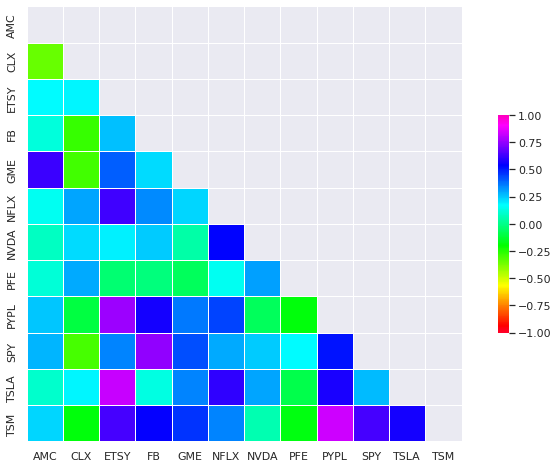

In [61]:
mask = np.triu(np.ones_like(C_full, dtype=bool))
f, ax = plt.subplots(figsize=(13, 8))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(C_full, mask=mask, cmap='gist_rainbow', vmin=-1.0, vmax=1.0, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, xticklabels=resid_df.columns, 
            yticklabels=resid_df.columns)

<AxesSubplot:>

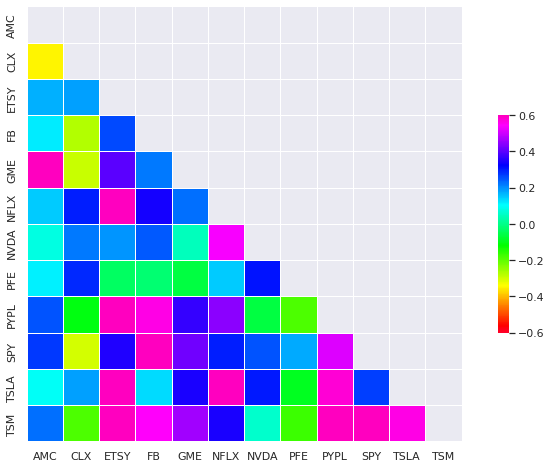

In [62]:
mask = np.triu(np.ones_like(C_glasso, dtype=bool))
f, ax = plt.subplots(figsize=(13, 8))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(C_glasso, mask=mask, cmap='gist_rainbow', vmin=-0.6, vmax=0.6, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, xticklabels=resid_df.columns, 
            yticklabels=resid_df.columns)

<AxesSubplot:>

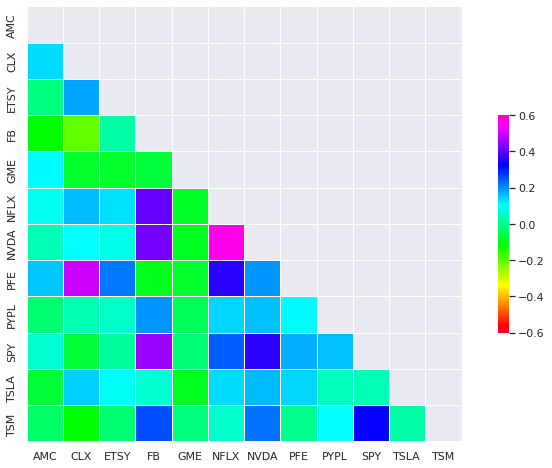

In [63]:
mask = np.triu(np.ones_like(C_minimal, dtype=bool))
f, ax = plt.subplots(figsize=(13, 8))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(C_minimal, mask=mask, cmap='gist_rainbow', vmin=-0.6, vmax=0.6, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, xticklabels=resid_df.columns, 
            yticklabels=resid_df.columns)

In [64]:
lrt_vals, p_vals, null_likelihoods, alt_likelihoods = LRT_covariance(data_total, window_size=window_size)

  0%|          | 0/59 [00:00<?, ?it/s]

Norm C_two, C_one:  6.657334693379238
Norm C_full, C_one:  3.327299693235363
Norm C_full, C_two:  3.330385489870588
Norm C_two, C_one:  6.659244451627838
Norm C_full, C_one:  3.3281764148519457
Norm C_full, C_two:  3.3314025087515433
Norm C_two, C_one:  6.660668753970499
Norm C_full, C_one:  3.3288371133692203
Norm C_full, C_two:  3.332155408391051
Norm C_two, C_one:  6.661705529234314
Norm C_full, C_one:  3.3293192902138764
Norm C_full, C_two:  3.3327027156413234
Norm C_two, C_one:  6.661742405867725
Norm C_full, C_one:  3.3292996701838784
Norm C_full, C_two:  3.332751735097959
Norm C_two, C_one:  6.661856976534314
Norm C_full, C_one:  3.3293115611931916
Norm C_full, C_two:  3.332845303155857
Norm C_two, C_one:  6.66118793865186
Norm C_full, C_one:  3.328911243768435
Norm C_full, C_two:  3.332563208316614
Norm C_two, C_one:  6.661433860218809
Norm C_full, C_one:  3.329023616734596
Norm C_full, C_two:  3.3326942858320123
Norm C_two, C_one:  6.66135908817873
Norm C_full, C_one:  3.32897

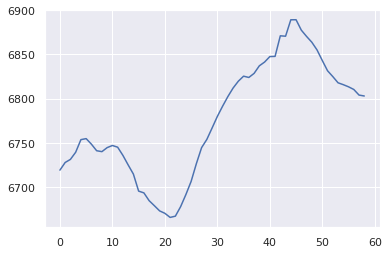

In [65]:
plt.plot(lrt_vals)

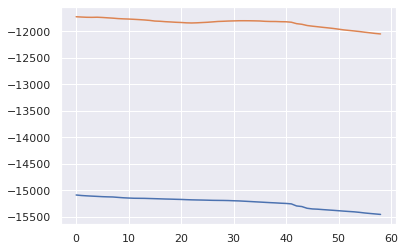

In [66]:
plt.plot(null_likelihoods)
plt.plot(alt_likelihoods)

In [91]:
lrt_vals, p_vals = LRT_all_coeffs_second_order(data_total, M=M, dim=dim, H_s=H_s, 
                                              window_size=window_size)

  0%|          | 0/59 [00:00<?, ?it/s]

(0.0, 8000.0)

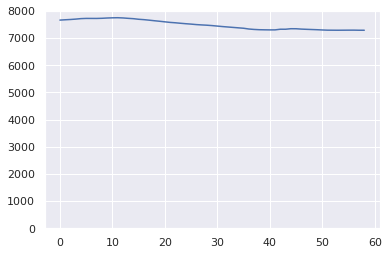

In [93]:
plt.plot(lrt_vals)
plt.ylim(0, 8000)

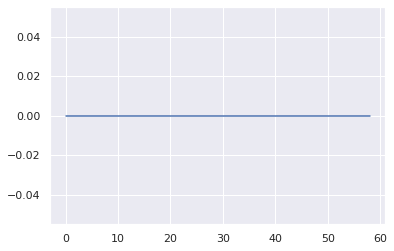

In [94]:
plt.plot(p_vals)

In [95]:
lrt_vals, p_vals = LRT_all_coeffs_first_order(data_total, M=M, dim=dim, H_s=H_s, 
                                              window_size=window_size, alpha=0.001, iters=1000, 
                                              use_unbiased_init=False)

  0%|          | 0/59 [00:00<?, ?it/s]

KeyboardInterrupt: 

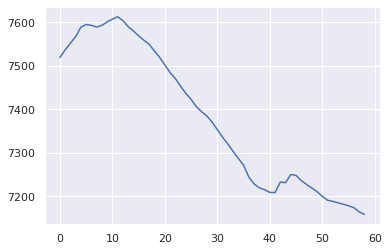

In [163]:
plt.plot(lrt_vals)

In [160]:
lrt_vals

[7169.058163501133,
 7209.769810020156,
 7238.855639629943,
 7261.580829348786,
 7294.773297216376,
 7300.445762284788,
 7296.204860149453,
 7286.692000893425,
 7290.790118347555,
 7298.385356755054,
 7305.229001274922,
 7316.137925237064,
 7304.892884705114,
 7291.262876160159,
 7283.844948485952,
 7288.0762728615555,
 7283.35627840439,
 7289.312750443292,
 7282.404144555945,
 7276.164885317121,
 7265.832447383509,
 7252.665779480907,
 7239.225832646964,
 7220.800905456832,
 7202.412409373257,
 7187.289262522605,
 7170.719224243894,
 7157.438866265526,
 7147.292287232693,
 7134.38865716225,
 7115.812277038829,
 7099.877438791995,
 7084.3637623407085,
 7052.291124042458,
 7026.594224118118,
 7002.672022167964,
 6975.320213232058,
 6957.286872254863,
 6947.845990573896,
 6939.3070084962455,
 6914.1956228090785,
 6905.391842920173,
 6952.3130221450665,
 6945.804288659383,
 6955.191724913544,
 6951.3014538338975,
 6933.287354772328,
 6929.412152784789,
 6911.89247122714,
 6901.39033894824

In [348]:
"""
Try it on the first half of the data

It works on the full data now that the sparsity has been undone

Egregious assumption of basis matrices is ruining this whole procedure
"""
data_first = data_total[:, 0:650]
C_first = np.cov(data_first, bias=True)
data_second = data_total[:, 650:]
C_second = np.cov(data_second, bias=True)
x0_first = unbiased_init_precision(C_first, H_s, N=data_first.shape[1], dim=M)
x0_second = unbiased_init_precision(C_second, H_s, N=data_second.shape[1], dim=M)

In [349]:
res = minimize(calc_likelihood_optim, x0_first, method='Nelder-Mead', args=(H_s, C_first, 
               data_first.shape[1], dim), options={'disp': True})

Optimization terminated successfully.
         Current function value: 6028.558381
         Iterations: 97
         Function evaluations: 177


In [350]:
res

 final_simplex: (array([[1.48627604, 1.60983201, 1.10846223],
       [1.48619818, 1.60980606, 1.10844269],
       [1.48628123, 1.60983154, 1.10852091],
       [1.48626113, 1.60976849, 1.10841843]]), array([6028.55838064, 6028.55838076, 6028.55838197, 6028.55838239]))
           fun: 6028.5583806399545
       message: 'Optimization terminated successfully.'
          nfev: 177
           nit: 97
        status: 0
       success: True
             x: array([1.48627604, 1.60983201, 1.10846223])

In [351]:
res.x

array([1.48627604, 1.60983201, 1.10846223])

In [357]:
coeffs_hat_first = iterative_soln_precision(x0_first, H_s, C_first, dim=M, iters=15)

LinAlgError: Singular matrix

In [353]:
res = minimize(calc_likelihood_optim, x0_second, method='Nelder-Mead', args=(H_s, C_second, 
               data_second.shape[1], dim), options={'disp': True})

Optimization terminated successfully.
         Current function value: 8910.706811
         Iterations: 75
         Function evaluations: 136


In [354]:
res

 final_simplex: (array([[0.76993022, 0.74733014, 0.79442773],
       [0.76995115, 0.74724364, 0.79437782],
       [0.77000766, 0.74735656, 0.79449554],
       [0.76998041, 0.74736055, 0.79444935]]), array([8910.70681106, 8910.70681353, 8910.70681696, 8910.70683048]))
           fun: 8910.706811064658
       message: 'Optimization terminated successfully.'
          nfev: 136
           nit: 75
        status: 0
       success: True
             x: array([0.76993022, 0.74733014, 0.79442773])

In [355]:
res.x

array([0.76993022, 0.74733014, 0.79442773])

In [358]:
coeffs_hat_second = iterative_soln_precision(x0_second, H_s, C_second, dim=M, iters=15)

In [359]:
coeffs_hat_second

array([15.72346776, 17.65730437, 31.40857029])